# BUSINESS UNDERSTANDING

## Latar Belakang

Produktivitas pertanian dipengaruhi oleh berbagai faktor seperti kondisi
iklim, curah hujan, suhu, penggunaan pestisida, jenis tanaman, dan wilayah.

Prediksi hasil panen dapat membantu memberikan estimasi produktivitas
sehingga dapat digunakan sebagai salah satu dasar dalam perencanaan
produksi pertanian.

## Tujuan

Membangun model untuk memprediksi hasil panen (hg/ha) berdasarkan:

- Wilayah (Area)
- Jenis tanaman (Item)
- Tahun
- Curah hujan
- Penggunaan pestisida
- Suhu rata-rata

## Tujuan Analisis

1. Mengidentifikasi pola hasil panen.
2. Mengetahui kontribusi faktor terhadap prediksi yield.
3. Membangun model prediksi yang memiliki performa baik.
4. Menghasilkan simulasi prediksi yang dapat digunakan sebagai
   decision-support sederhana.

## Batasan

Dataset bersifat observasional sehingga hubungan yang ditemukan
merupakan asosiasi dan tidak dapat langsung dianggap sebagai
hubungan sebab-akibat.

# Data Understanding

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("patelris/crop-yield-prediction-dataset")

print("Path to dataset files:", path)

In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/crop-yield-prediction-dataset/yield_df.csv")

print("Ukuran dataset:", df.shape)

df.head()

Ukuran dataset: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


Pada tahap awal, dataset dimuat menggunakan Pandas dan kemudian dilakukan pengecekan terhadap ukuran serta beberapa data pertama. Dataset yang digunakan memiliki 28.242 baris dan 8 kolom. Data ini berisi informasi mengenai wilayah, jenis tanaman, tahun, hasil produksi per hektare, curah hujan, penggunaan pestisida, dan suhu. Pengecekan lima data pertama dilakukan untuk memastikan struktur dan isi dataset sudah sesuai dengan kebutuhan analisis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


Berdasarkan hasil pengecekan struktur data, dataset memiliki 28.242 baris dan 8 kolom. Seluruh kolom memiliki jumlah data yang lengkap, sehingga tidak ditemukan missing value. Data terdiri dari variabel kategorikal seperti wilayah dan jenis tanaman, serta variabel numerik seperti tahun, hasil produksi, curah hujan, penggunaan pestisida, dan suhu. Informasi ini digunakan sebagai dasar untuk menentukan tahapan preprocessing selanjutnya.

In [ ]:
missing = df.isnull().sum()

print("Missing value:")
print(missing)

print("\nTotal missing value:", missing.sum())

Missing value:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Total missing value: 0


Selanjutnya dilakukan pengecekan missing value untuk memastikan apakah terdapat data yang kosong pada setiap variabel. Hasil pemeriksaan menunjukkan bahwa seluruh variabel memiliki 0 missing value, sehingga dari sisi kelengkapan data, seluruh 28.242 observasi telah terisi dan tidak diperlukan proses penanganan missing value.

In [ ]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


Selanjutnya dilakukan pengecekan data duplikat untuk memastikan tidak ada baris data yang tercatat lebih dari satu kali. Hasil pemeriksaan menunjukkan jumlah data duplikat adalah 0, sehingga seluruh baris dalam dataset tidak memiliki duplikasi yang identik dan data dapat dilanjutkan ke tahap analisis berikutnya.

In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.head())

      Area         Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0  Albania        Maize  1990        36613                         1485.0   
1  Albania     Potatoes  1990        66667                         1485.0   
2  Albania  Rice, paddy  1990        23333                         1485.0   
3  Albania      Sorghum  1990        12500                         1485.0   
4  Albania     Soybeans  1990         7000                         1485.0   

   pesticides_tonnes  avg_temp  
0              121.0     16.37  
1              121.0     16.37  
2              121.0     16.37  
3              121.0     16.37  
4              121.0     16.37  


Pada tahap data cleaning, kami menghapus kolom Unnamed: 0 karena kolom tersebut hanya merupakan nomor indeks dari dataset dan tidak memberikan informasi yang dibutuhkan dalam proses analisis maupun prediksi hasil panen. Setelah kolom tersebut dihapus, dilakukan pengecekan menggunakan head() untuk memastikan bahwa data sudah bersih dan kolom yang digunakan hanya merupakan variabel yang relevan.

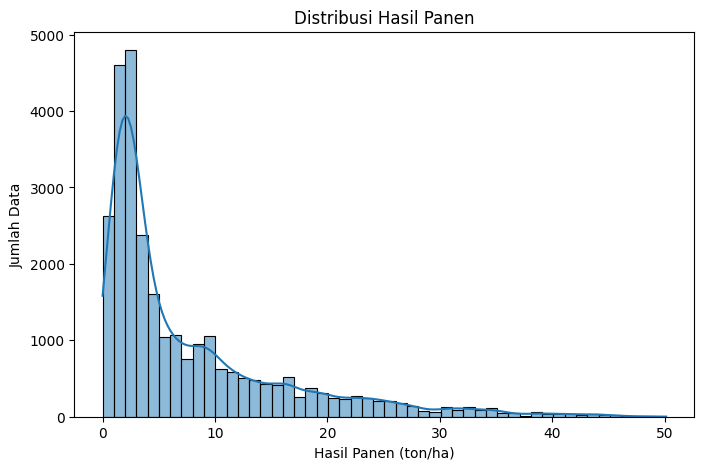

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df["hg/ha_yield"] / 10000,
    bins=50,
    kde=True
)

plt.title("Distribusi Hasil Panen")
plt.xlabel("Hasil Panen (ton/ha)")
plt.ylabel("Jumlah Data")

plt.show()

Grafik ini menunjukkan bagaimana hasil panen tersebar pada seluruh data yang digunakan. Sumbu horizontal menunjukkan hasil panen dalam ton per hektare, sedangkan sumbu vertikal menunjukkan jumlah data. Dari grafik terlihat bahwa sebagian besar data memiliki hasil panen di bawah sekitar 10 ton per hektare. Jumlah data semakin sedikit ketika hasil panen semakin tinggi.

Di sisi kanan grafik masih terdapat beberapa data dengan hasil panen yang cukup tinggi, bahkan mencapai sekitar 50 ton per hektare. Artinya, hanya sebagian kecil data yang memiliki hasil panen jauh lebih tinggi dibandingkan sebagian besar data. Temuan ini menunjukkan bahwa hasil panen dalam dataset memiliki rentang yang cukup lebar dan persebarannya tidak merata. Oleh karena itu, kondisi tersebut perlu diperhatikan dalam tahap pengolahan data dan pemodelan.

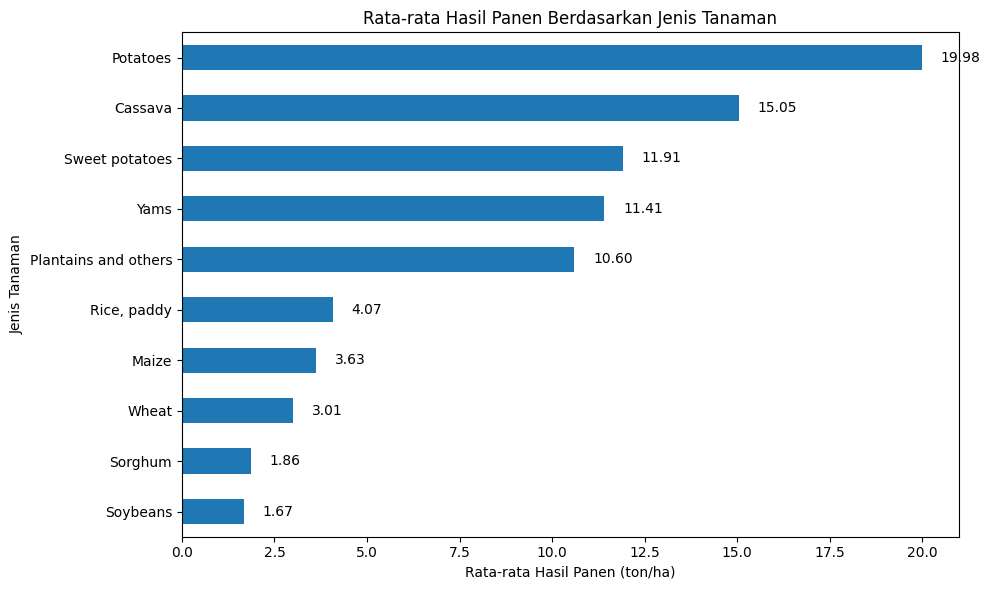

In [ ]:
yield_item = (
    df.groupby("Item")["hg/ha_yield"]
    .mean()
    .sort_values(ascending=False)
)

# Konversi hg/ha ke ton/ha
yield_item = yield_item / 10000

# Urutkan dari rendah ke tinggi agar grafik bar enak dibaca
yield_item = yield_item.sort_values()

plt.figure(figsize=(10, 6))

ax = yield_item.plot(kind="barh")

plt.title("Rata-rata Hasil Panen Berdasarkan Jenis Tanaman")
plt.xlabel("Rata-rata Hasil Panen (ton/ha)")
plt.ylabel("Jenis Tanaman")

# Menampilkan angka pada setiap batang
for i, value in enumerate(yield_item):
    ax.text(
        value + 0.5,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

Grafik ini menunjukkan perbedaan rata-rata hasil panen dari berbagai jenis tanaman dalam satu hektare lahan. Terlihat bahwa kentang memiliki rata-rata hasil panen paling tinggi, yaitu sekitar 19,98 ton per hektare. Setelah itu terdapat singkong sebesar 15,05 ton per hektare dan ubi jalar sebesar 11,91 ton per hektare. Sementara itu, kedelai memiliki rata-rata hasil panen paling rendah, yaitu sekitar 1,67 ton per hektare.

Dari grafik tersebut dapat dilihat bahwa setiap jenis tanaman memiliki rata-rata hasil panen yang berbeda cukup jauh. Hal ini menunjukkan bahwa jenis tanaman merupakan salah satu informasi penting yang perlu dipertimbangkan ketika melakukan prediksi hasil panen.

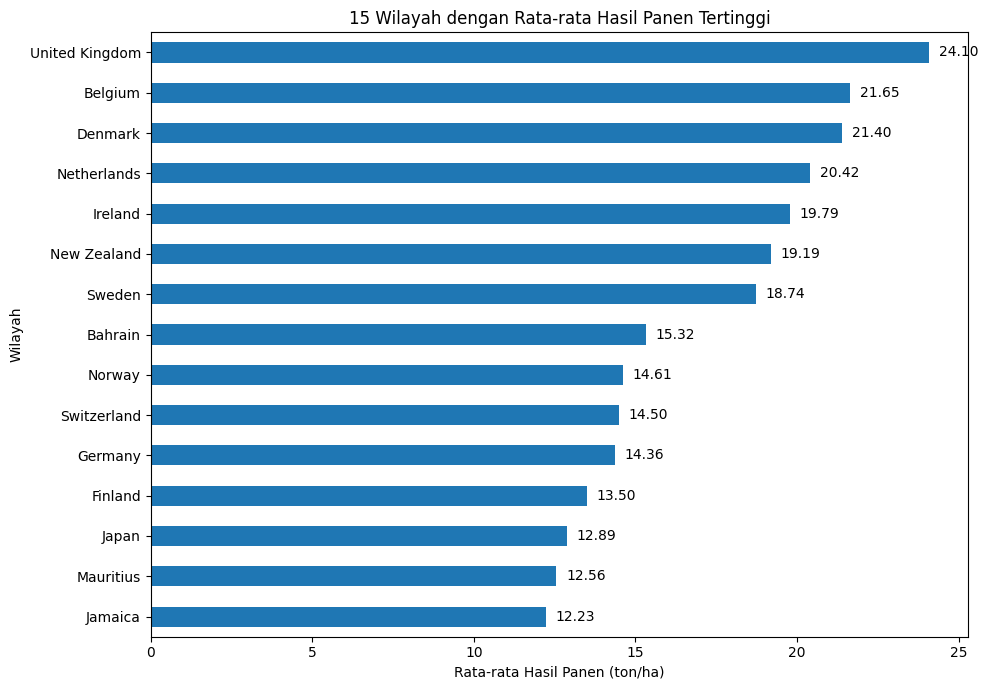

In [ ]:
rata_area = (
    df.groupby("Area")["hg/ha_yield"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# Konversi ke ton/ha
rata_area = rata_area / 10000

rata_area = rata_area.sort_values()

plt.figure(figsize=(10, 7))

ax = rata_area.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title(
    "15 Wilayah dengan Rata-rata Hasil Panen Tertinggi"
)

plt.xlabel("Rata-rata Hasil Panen (ton/ha)")
plt.ylabel("Wilayah")

for i, value in enumerate(rata_area):
    ax.text(
        value + 0.3,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

Grafik ini menunjukkan 15 wilayah yang memiliki rata-rata hasil panen per hektare paling tinggi dalam dataset. Dari grafik terlihat bahwa United Kingdom memiliki rata-rata hasil panen tertinggi, yaitu sekitar 24,10 ton per hektare. Selanjutnya adalah Belgium sebesar 21,65 ton per hektare dan Denmark sebesar 21,40 ton per hektare.

Sementara itu, Jamaica berada di posisi ke-15 dengan rata-rata 12,23 ton per hektare. Perbedaan ini menunjukkan bahwa rata-rata hasil panen tidak sama di setiap wilayah. Hal tersebut menjadi indikasi bahwa karakteristik wilayah merupakan informasi yang penting untuk dipertimbangkan dalam melakukan prediksi hasil panen.

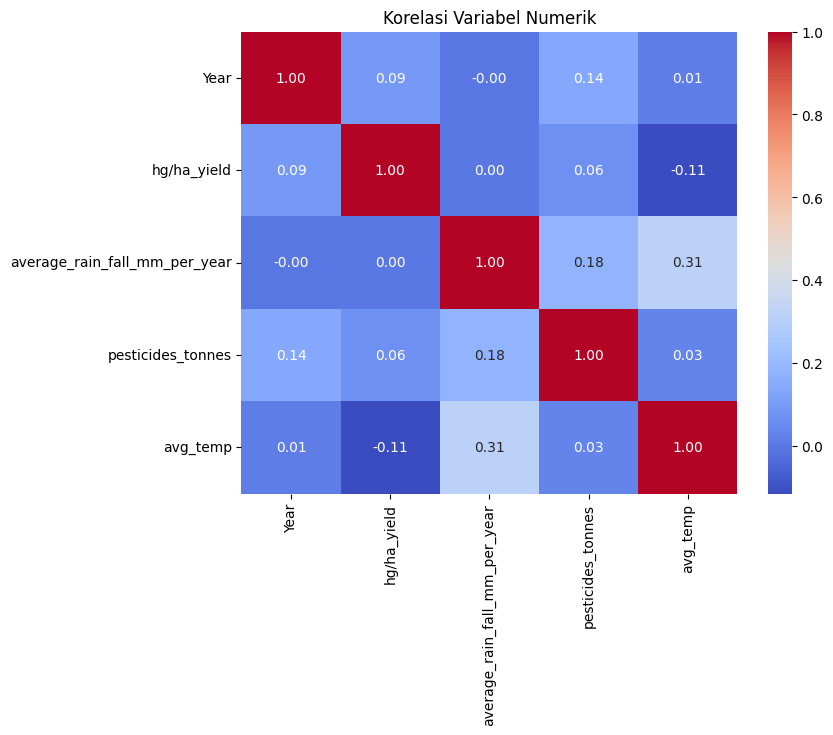

In [ ]:
numeric_cols = [
    "Year",
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Korelasi Variabel Numerik")

plt.show()

Dari grafik terlihat bahwa hubungan antara tahun dan hasil panen hanya sebesar 0,09, sehingga hubungannya sangat lemah. Hubungan antara curah hujan dan hasil panen adalah 0,00, sedangkan jumlah penggunaan pestisida dan hasil panen sebesar 0,06. Artinya, berdasarkan data ini, hubungan langsung kedua faktor tersebut dengan hasil panen terlihat sangat lemah.

Sementara itu, suhu rata-rata dan hasil panen memiliki nilai -0,11. Tanda negatif menunjukkan bahwa ketika suhu meningkat, hasil panen dalam data cenderung sedikit menurun, tetapi hubungannya juga masih sangat lemah. Hubungan numerik yang paling terlihat pada grafik adalah curah hujan dengan suhu rata-rata, yaitu 0,31, tetapi hubungan ini juga masih tergolong lemah.

# Data Preparation

In [ ]:
import numpy as np

df["log_yield"] = np.log1p(df["hg/ha_yield"])

print(df[["hg/ha_yield", "log_yield"]].head())

   hg/ha_yield  log_yield
0        36613  10.508186
1        66667  11.107480
2        23333  10.057667
3        12500   9.433564
4         7000   8.853808


Pada tahap ini, kita melakukan transformasi data hasil panen. Sebelumnya, dari grafik distribusi hasil panen, kita sudah melihat bahwa nilai hasil panen memiliki rentang yang sangat lebar. Sebagian besar data berada pada nilai yang relatif rendah, tetapi ada sebagian kecil data dengan hasil panen yang sangat tinggi, sehingga kita perlu mengubahnya ke dalam bentuk logaritma. Tujuannya adalah untuk mengecilkan perbedaan skala antar nilai agar data lebih terkendali dan lebih mudah digunakan dalam proses pemodelan. Data hasil panen asli tetap dipertahankan, sedangkan hasil transformasinya disimpan sebagai kolom baru log_yield





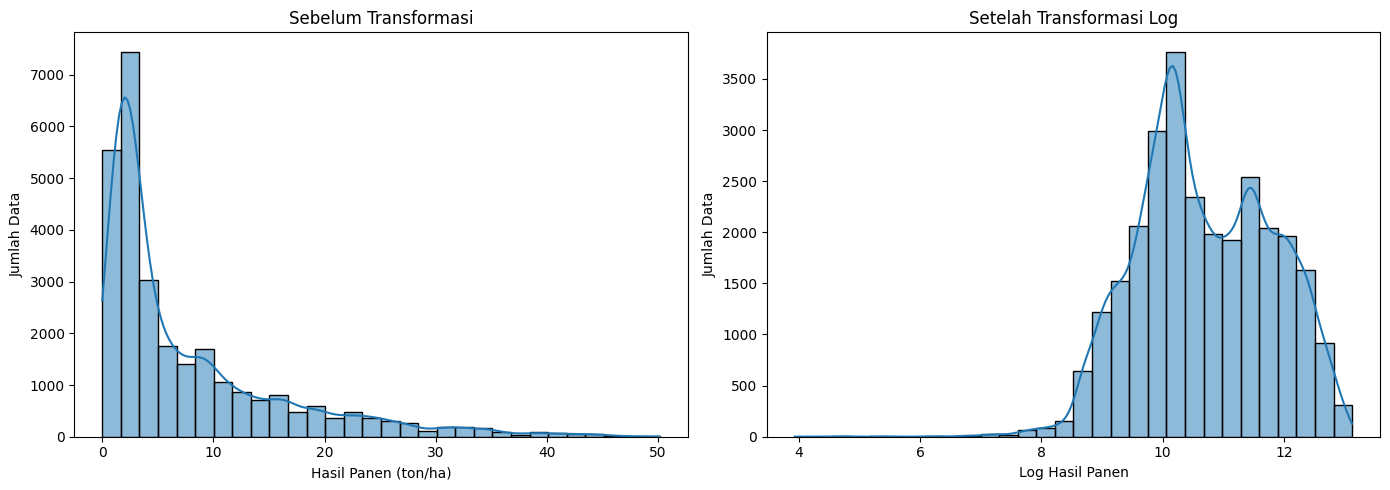

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum transformasi
sns.histplot(
    df["hg/ha_yield"] / 10000,
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Sebelum Transformasi")
axes[0].set_xlabel("Hasil Panen (ton/ha)")
axes[0].set_ylabel("Jumlah Data")


# Sesudah transformasi
sns.histplot(
    df["log_yield"],
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Setelah Transformasi Log")
axes[1].set_xlabel("Log Hasil Panen")
axes[1].set_ylabel("Jumlah Data")

plt.tight_layout()
plt.show()

Gambar ini membandingkan persebaran hasil panen sebelum dan sesudah dilakukan transformasi logaritma. Pada grafik sebelah kiri, yaitu sebelum transformasi, sebagian besar hasil panen berada pada nilai yang rendah, sementara hanya sedikit data yang memiliki hasil panen sangat tinggi hingga sekitar 50 ton per hektare. Akibatnya, persebaran data terlihat memanjang ke arah kanan.

Pada grafik sebelah kanan, yaitu setelah transformasi log, rentang nilai menjadi lebih terkendali. Nilai hasil panen yang sebelumnya memiliki perbedaan sangat besar sekarang berada pada rentang yang lebih sempit. Persebaran data juga menjadi lebih merata dibandingkan sebelumnya. Dengan demikian, transformasi log membantu mengurangi kemiringan persebaran data dan membuat skala hasil panen lebih terkendali untuk digunakan dalam proses pemodelan.

In [ ]:
TRAIN_CUTOFF = 2009

train_df = df[df["Year"] <= TRAIN_CUTOFF].copy()
test_df = df[df["Year"] > TRAIN_CUTOFF].copy()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

print("\nTahun train:",
      train_df["Year"].min(),
      "-",
      train_df["Year"].max())

print("Tahun test :",
      test_df["Year"].min(),
      "-",
      test_df["Year"].max())

Train: (23233, 8)
Test : (5009, 8)

Tahun train: 1990 - 2009
Tahun test : 2010 - 2013


Pada tahap ini, kita melakukan pembagian data menjadi data latih (train) dan data uji (test) berdasarkan tahun. Data tahun 1990–2009 digunakan sebagai data latih agar model dapat mempelajari pola hasil panen dari data masa lalu, sedangkan data tahun 2010–2013 digunakan sebagai data uji untuk melihat apakah model mampu memberikan prediksi yang baik pada periode setelahnya. Pembagian berdasarkan waktu ini dipilih agar proses pengujian lebih mendekati kondisi nyata, yaitu model belajar dari data masa lalu kemudian digunakan untuk memprediksi data di masa berikutnya.

Output Train: (23233, 8) menunjukkan bahwa terdapat 23.233 data dengan 8 variabel yang digunakan untuk melatih model. Sementara Test: (5009, 8) berarti terdapat 5.009 data dengan 8 variabel yang disimpan untuk menguji model. Jadi, dari total 28.242 data, sebanyak 23.233 digunakan untuk belajar dan 5.009 digunakan untuk pengujian. Pembagian tahun yang ditampilkan juga memastikan bahwa data masa depan (2010–2013) tidak ikut digunakan saat model belajar, sehingga hasil evaluasi menjadi lebih realistis.

In [ ]:
baseline_map = (
    train_df
    .groupby(["Area", "Item"])["log_yield"]
    .mean()
)

global_mean = train_df["log_yield"].mean()


def get_baseline_prediction(data):
    return data.apply(
        lambda row: baseline_map.get(
            (row["Area"], row["Item"]),
            global_mean
        ),
        axis=1
    )

train_df["baseline_log_pred"] = get_baseline_prediction(train_df)
test_df["baseline_log_pred"] = get_baseline_prediction(test_df)

Kode baseline_map digunakan untuk menghitung rata-rata log_yield berdasarkan Area dan Item, sedangkan global_mean digunakan sebagai nilai cadangan apabila terdapat kombinasi wilayah dan tanaman pada data uji yang sebelumnya tidak ditemukan pada data latih. Setelah itu, hasil rata-rata tersebut dimasukkan ke kolom baru bernama baseline_log_pred pada data train dan test.

Tujuan utamanya adalah membuat titik pembanding. Nanti setelah kita membuat model seperti Random Forest atau XGBoost, performanya akan dibandingkan dengan baseline ini. Kalau model machine learning ternyata memberikan hasil yang jauh lebih baik daripada baseline, berarti model tersebut memang berhasil menemukan pola yang lebih kompleks daripada sekadar menggunakan rata-rata hasil panen.

In [ ]:
train_df["residual"] = (
    train_df["log_yield"]
    - train_df["baseline_log_pred"]
)

test_df["residual"] = (
    test_df["log_yield"]
    - test_df["baseline_log_pred"]
)

print(train_df["residual"].describe())

count    2.323300e+04
mean    -3.303001e-17
std      2.153675e-01
min     -2.503371e+00
25%     -8.567281e-02
50%      3.659983e-03
75%      9.314335e-02
max      2.298740e+00
Name: residual, dtype: float64


Pada tahap ini, kita sedang melakukan analisis residual, yaitu melihat seberapa jauh hasil prediksi baseline berbeda dari hasil panen yang sebenarnya. Sederhananya, residual adalah selisih antara nilai sebenarnya dengan nilai yang diprediksi. Tujuannya adalah untuk mengetahui apakah prediksi baseline sudah cukup mendekati kondisi sebenarnya atau masih memiliki kesalahan yang cukup besar.

Output tersebut menunjukkan ringkasan dari 23.233 residual pada data train. Nilai mean hampir 0 (-3,30 × 10⁻¹⁷), yang menunjukkan bahwa secara rata-rata kesalahan prediksi berada di sekitar nol. Nilai 50% atau median adalah 0,00366, sehingga setengah data memiliki residual di bawah nilai tersebut dan setengah lainnya di atasnya. Sementara itu, residual terkecil adalah -2,50 dan terbesar 2,30, yang menunjukkan bahwa pada beberapa data terdapat perbedaan yang cukup jauh antara hasil sebenarnya dan prediksi baseline.

In [ ]:
FEATURES = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

# Tambahkan fitur interaksi sederhana
for data in [train_df, test_df]:

    data["rainfall_temp"] = (
        data["average_rain_fall_mm_per_year"]
        * data["avg_temp"]
    )

    data["pesticide_per_year"] = (
        data["pesticides_tonnes"]
        / (data["Year"] - 1989 + 1)
    )

FEATURES += [
    "rainfall_temp",
    "pesticide_per_year"
]

Pada tahap ini, kita sedang melakukan pemilihan dan penambahan fitur (feature engineering) sebelum data dimasukkan ke model. Sederhananya, kita memilih informasi yang dianggap dapat membantu model memprediksi hasil panen, kemudian membuat dua informasi tambahan dari data yang sudah ada agar model dapat menangkap hubungan yang lebih kompleks.

Fitur awal yang digunakan adalah tahun, curah hujan, jumlah penggunaan pestisida, dan suhu rata-rata. Kemudian kita membuat fitur rainfall_temp, yaitu perkalian antara curah hujan dan suhu. Tujuannya adalah memberikan informasi kepada model mengenai kombinasi kondisi curah hujan dan suhu, bukan hanya melihat keduanya secara terpisah. Selanjutnya dibuat pesticide_per_year, yaitu jumlah pestisida dibagi berdasarkan lama periode tahun yang dihitung dari 1990. Ini memberikan gambaran penggunaan pestisida per tahun.

In [ ]:
item_train = pd.get_dummies(
    train_df["Item"],
    prefix="item"
)

item_test = pd.get_dummies(
    test_df["Item"],
    prefix="item"
)

# Pastikan kolom train dan test sama
item_test = item_test.reindex(
    columns=item_train.columns,
    fill_value=0
)

Pada tahap ini, kita sedang melakukan pengubahan data jenis tanaman menjadi bentuk angka agar bisa dibaca oleh model machine learning. Kolom Item berisi nama tanaman seperti Wheat, Potatoes, Rice, dan sebagainya, sehingga tidak bisa langsung digunakan oleh sebagian besar model dalam bentuk teks. Oleh karena itu, kita menggunakan one-hot encoding, yaitu mengubah setiap jenis tanaman menjadi kolom tersendiri yang berisi nilai 1 jika tanaman tersebut sesuai dan 0 jika tidak.

In [ ]:
X_train = pd.concat(
    [
        train_df[FEATURES].reset_index(drop=True),
        item_train.reset_index(drop=True)
    ],
    axis=1
)

X_test = pd.concat(
    [
        test_df[FEATURES].reset_index(drop=True),
        item_test.reset_index(drop=True)
    ],
    axis=1
)

y_train = train_df["residual"]
y_test = test_df["residual"]

print("Jumlah fitur:", X_train.shape[1])
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Jumlah fitur: 16
X_train: (23233, 16)
X_test : (5009, 16)


Pada tahap ini, kita sedang menyatukan seluruh informasi yang sudah disiapkan menjadi data akhir yang akan digunakan untuk melatih dan menguji model machine learning. Jadi, sebelumnya kita sudah membuat beberapa fitur numerik seperti tahun, curah hujan, pestisida, suhu, serta fitur tambahan, dan juga mengubah jenis tanaman menjadi angka 0 dan 1 menggunakan one-hot encoding. Sekarang semua fitur tersebut digabungkan menjadi satu tabel yang disebut X, yaitu informasi yang akan dibaca oleh model. Sementara itu, y berisi nilai yang ingin diprediksi oleh model, yaitu residual atau kesalahan prediksi baseline.

Output Jumlah fitur: 16 berarti setelah semua informasi digabungkan, model akan menerima 16 variabel sebagai bahan untuk membuat prediksi. X_train: (23233, 16) berarti terdapat 23.233 data latihan dengan 16 variabel, sedangkan X_test: (5009, 16) berarti terdapat 5.009 data pengujian dengan 16 variabel. Jadi, pada tahap ini kita sudah memiliki bentuk data yang siap diberikan kepada model: 23.233 data untuk belajar dan 5.009 data untuk menguji kemampuan model.

# Modelling

In [ ]:
# ==========================================
# MODELING - PERBANDINGAN BEBERAPA ALGORITMA
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ------------------------------------------
# 1. Linear Regression
# ------------------------------------------
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression berhasil dilatih.")


# ------------------------------------------
# 2. Random Forest
# ------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest berhasil dilatih.")


# ------------------------------------------
# 3. XGBoost
# ------------------------------------------
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost berhasil dilatih.")

Linear Regression berhasil dilatih.
Random Forest berhasil dilatih.
XGBoost berhasil dilatih.


Pada tahap ini kita masuk ke proses pemodelan (modeling). Tujuannya adalah melatih beberapa algoritma machine learning menggunakan data X_train sebagai informasi atau faktor yang digunakan untuk melakukan prediksi, sedangkan y_train merupakan nilai yang ingin diprediksi, yaitu residual dari log yield. Kita menggunakan tiga algoritma, yaitu Linear Regression, Random Forest, dan XGBoost, agar dapat mengetahui pendekatan mana yang paling sesuai untuk data hasil panen. Ketiga model dilatih menggunakan data dan kondisi yang sama sehingga hasilnya dapat dibandingkan secara adil.

Linear Regression digunakan sebagai model sederhana atau pembanding awal. Model ini mencoba menemukan hubungan garis lurus antara faktor-faktor seperti tahun, curah hujan, pestisida, suhu, dan jenis tanaman dengan residual hasil panen. Random Forest menggunakan banyak pohon keputusan dan menggabungkan hasilnya untuk menghasilkan prediksi yang lebih stabil. Sementara itu, XGBoost juga menggunakan pohon keputusan, tetapi membangunnya secara bertahap dengan berusaha memperbaiki kesalahan prediksi dari model sebelumnya. Dengan demikian, ketiga algoritma memiliki pendekatan yang berbeda dalam mempelajari pola data.

Bagian seperti n_estimators=300 pada Random Forest berarti model membuat 300 pohon keputusan. Pada XGBoost, n_estimators=400 berarti menggunakan hingga 400 tahap/pohon, sedangkan max_depth=4 membatasi kedalaman setiap pohon agar model tidak terlalu kompleks. learning_rate=0.05 mengatur seberapa besar kontribusi setiap tahap XGBoost terhadap hasil akhir. random_state=42 digunakan agar proses yang memiliki unsur acak dapat menghasilkan hasil yang konsisten ketika kode dijalankan kembali.

In [ ]:
# ==========================================
# PREDIKSI RESIDUAL
# ==========================================

# Linear Regression
predicted_residual_linear = linear_model.predict(X_test)

# Random Forest
predicted_residual_rf = rf_model.predict(X_test)

# XGBoost
predicted_residual_xgb = xgb_model.predict(X_test)


# ==========================================
# GABUNGKAN DENGAN BASELINE
# ==========================================

predicted_log_linear = (
    test_df["baseline_log_pred"].values
    + predicted_residual_linear
)

predicted_log_rf = (
    test_df["baseline_log_pred"].values
    + predicted_residual_rf
)

predicted_log_xgb = (
    test_df["baseline_log_pred"].values
    + predicted_residual_xgb
)


# ==========================================
# KEMBALIKAN KE SKALA ASLI
# ==========================================

predicted_yield_linear = np.expm1(predicted_log_linear)
predicted_yield_rf = np.expm1(predicted_log_rf)
predicted_yield_xgb = np.expm1(predicted_log_xgb)


# ==========================================
# TIDAK BOLEH NEGATIF
# ==========================================

predicted_yield_linear = np.clip(
    predicted_yield_linear, 0, None
)

predicted_yield_rf = np.clip(
    predicted_yield_rf, 0, None
)

predicted_yield_xgb = np.clip(
    predicted_yield_xgb, 0, None
)

Pada tahap ini, tiga algoritma yang sudah dilatih digunakan untuk memprediksi data yang belum mereka lihat, yaitu data test. Masing-masing model terlebih dahulu memprediksi residual atau perbaikan terhadap baseline. Prediksi tersebut kemudian digabungkan dengan baseline, dikembalikan dari skala log ke skala yield asli, dan dipastikan tidak menghasilkan nilai negatif. Hasil akhirnya adalah tiga prediksi yield yang nantinya digunakan untuk membandingkan Linear Regression, Random Forest, dan XGBoost menggunakan MAE, RMSE, dan R².

# Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================
# EVALUASI SEMUA MODEL
# ============================================

actual_yield = test_df["hg/ha_yield"].values


# --------------------------------------------
# Linear Regression
# --------------------------------------------

mae_linear = mean_absolute_error(
    actual_yield,
    predicted_yield_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        actual_yield,
        predicted_yield_linear
    )
)

r2_linear = r2_score(
    actual_yield,
    predicted_yield_linear
)


# --------------------------------------------
# Random Forest
# --------------------------------------------

mae_rf = mean_absolute_error(
    actual_yield,
    predicted_yield_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        actual_yield,
        predicted_yield_rf
    )
)

r2_rf = r2_score(
    actual_yield,
    predicted_yield_rf
)


# --------------------------------------------
# XGBoost
# --------------------------------------------

mae_xgb = mean_absolute_error(
    actual_yield,
    predicted_yield_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        actual_yield,
        predicted_yield_xgb
    )
)

r2_xgb = r2_score(
    actual_yield,
    predicted_yield_xgb
)


# ============================================
# TAMPILKAN HASIL
# ============================================

print("=== HASIL EVALUASI ===")

print("\nLinear Regression")
print(f"MAE  : {mae_linear:,.2f}")
print(f"RMSE : {rmse_linear:,.2f}")
print(f"R²   : {r2_linear:.4f}")

print("\nRandom Forest")
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

print("\nXGBoost")
print(f"MAE  : {mae_xgb:,.2f}")
print(f"RMSE : {rmse_xgb:,.2f}")
print(f"R²   : {r2_xgb:.4f}")

=== HASIL EVALUASI ===

Linear Regression
MAE  : 14,520.59
RMSE : 26,670.67
R²   : 0.9221

Random Forest
MAE  : 10,591.88
RMSE : 21,294.82
R²   : 0.9503

XGBoost
MAE  : 12,839.31
RMSE : 24,312.76
R²   : 0.9352


Pada tahap ini kita melakukan evaluasi dan perbandingan performa tiga algoritma yang sebelumnya sudah dilatih, yaitu Linear Regression, Random Forest, dan XGBoost. Tujuannya adalah mengetahui seberapa dekat hasil prediksi masing-masing model dengan hasil panen sebenarnya (actual_yield) pada data test. Karena ketiga model menggunakan data test yang sama, hasilnya dapat dibandingkan secara adil.

Untuk mengukurnya digunakan tiga metrik, yaitu MAE, RMSE, dan R². MAE menunjukkan rata-rata seberapa jauh prediksi model dari nilai sebenarnya; semakin kecil nilainya semakin baik. RMSE juga mengukur kesalahan prediksi, tetapi memberikan hukuman lebih besar terhadap kesalahan yang sangat jauh; semakin kecil semakin baik. Sedangkan R² menunjukkan seberapa baik model mampu menjelaskan variasi hasil panen; semakin mendekati 1 atau 100% berarti semakin baik.

Dari hasil tersebut, Random Forest menjadi model terbaik di antara ketiga model yang kamu uji. Random Forest memiliki MAE paling kecil, yaitu 10.591,88, yang berarti rata-rata kesalahan prediksinya paling rendah. Random Forest juga memiliki RMSE paling kecil, yaitu 21.294,82, dan R² paling tinggi, yaitu 0,9503 atau sekitar 95,03%.

Sementara itu, XGBoost memperoleh R² sebesar 93,52%, sehingga performanya masih cukup baik tetapi pada pengujian ini belum mengungguli Random Forest. Linear Regression memiliki performa paling rendah dari ketiganya dengan R² 92,21%.

In [ ]:
# ============================================
# EVALUASI BASELINE
# ============================================

baseline_predicted = np.expm1(
    test_df["baseline_log_pred"]
)

baseline_predicted = np.clip(
    baseline_predicted,
    0,
    None
)

baseline_r2 = r2_score(
    actual_yield,
    baseline_predicted
)

baseline_mae = mean_absolute_error(
    actual_yield,
    baseline_predicted
)


# ============================================
# TAMPILKAN HASIL PERBANDINGAN
# ============================================

print("=== BASELINE ===")
print(f"MAE : {baseline_mae:,.2f}")
print(f"R²  : {baseline_r2:.4f}")


print("\n=== LINEAR REGRESSION ===")
print(f"MAE : {mae_linear:,.2f}")
print(f"R²  : {r2_linear:.4f}")
print(
    f"Peningkatan R²: {r2_linear - baseline_r2:.4f}"
)


print("\n=== RANDOM FOREST ===")
print(f"MAE : {mae_rf:,.2f}")
print(f"R²  : {r2_rf:.4f}")
print(
    f"Peningkatan R²: {r2_rf - baseline_r2:.4f}"
)


print("\n=== XGBOOST ===")
print(f"MAE : {mae_xgb:,.2f}")
print(f"R²  : {r2_xgb:.4f}")
print(
    f"Peningkatan R²: {r2_xgb - baseline_r2:.4f}"
)

=== BASELINE ===
MAE : 18,581.48
R²  : 0.8781

=== LINEAR REGRESSION ===
MAE : 14,520.59
R²  : 0.9221
Peningkatan R²: 0.0439

=== RANDOM FOREST ===
MAE : 10,591.88
R²  : 0.9503
Peningkatan R²: 0.0722

=== XGBOOST ===
MAE : 12,839.31
R²  : 0.9352
Peningkatan R²: 0.0571


Pada tahap ini, kami membandingkan baseline dengan tiga algoritma machine learning menggunakan MAE dan R². Baseline memperoleh R² sebesar 87,81%. Setelah menggunakan machine learning, Linear Regression meningkat menjadi 92,21%, XGBoost menjadi 93,52%, dan Random Forest mencapai 95,03%. Random Forest juga memiliki MAE terendah sebesar 10.591,88. Berdasarkan hasil tersebut, Random Forest dipilih sebagai model dengan performa terbaik pada data pengujian.

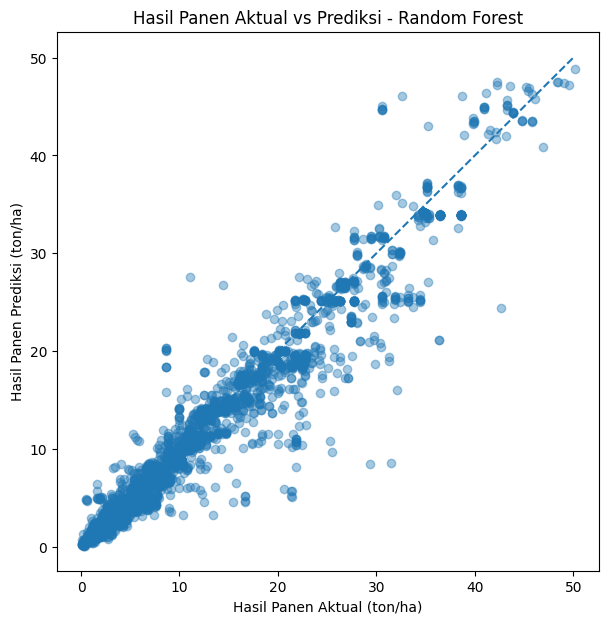

In [ ]:
import matplotlib.pyplot as plt

# ============================================
# KONVERSI DARI hg/ha KE ton/ha
# ============================================

actual_yield_ton = actual_yield / 10000
predicted_yield_rf_ton = predicted_yield_rf / 10000


# ============================================
# GRAFIK HASIL PANEN AKTUAL VS PREDIKSI
# ============================================

plt.figure(figsize=(7,7))

plt.scatter(
    actual_yield_ton,
    predicted_yield_rf_ton,
    alpha=0.4
)


# Menentukan batas grafik
min_val = min(
    actual_yield_ton.min(),
    predicted_yield_rf_ton.min()
)

max_val = max(
    actual_yield_ton.max(),
    predicted_yield_rf_ton.max()
)


# Garis prediksi sempurna
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)


# ============================================
# LABEL GRAFIK
# ============================================

plt.xlabel("Hasil Panen Aktual (ton/ha)")
plt.ylabel("Hasil Panen Prediksi (ton/ha)")

plt.title(
    "Hasil Panen Aktual vs Prediksi - Random Forest"
)

plt.show()

Pada tahap ini, kita membuat grafik untuk mengecek seberapa dekat hasil prediksi Random Forest dengan hasil panen sebenarnya. Jadi, grafik ini bukan untuk melatih model lagi, tetapi untuk memvisualisasikan kualitas prediksi model.

Pertama, hasil panen dalam dataset masih menggunakan satuan hg/ha. Karena satuan tersebut kurang familiar bagi orang awam, kita mengubahnya menjadi ton/ha dengan membagi nilainya dengan 10.000, karena 1 ton = 10.000 hg. Setelah itu, hasil panen aktual dan hasil prediksi Random Forest digunakan sebagai sumbu grafik.

Pada grafik, sumbu X (horizontal) menunjukkan hasil panen yang sebenarnya, sedangkan sumbu Y (vertikal) menunjukkan hasil panen yang diprediksi oleh Random Forest. Setiap titik mewakili satu data tanaman pada suatu wilayah dan tahun.

Garis putus-putus diagonal adalah garis kondisi ideal. Misalnya, jika hasil panen sebenarnya 20 ton/ha dan model juga memprediksi 20 ton/ha, titiknya akan berada tepat di garis tersebut. Jadi, semakin dekat titik-titik dengan garis putus-putus, semakin dekat prediksi model dengan kenyataan.

Pada tahap ini kami menggunakan SHAP untuk menginterpretasikan model dan mengetahui fitur mana yang paling berpengaruh terhadap prediksi. Berdasarkan hasil visualisasi, tahun menjadi fitur yang paling dominan, diikuti oleh penggunaan pestisida, penggunaan pestisida per tahun, jenis tanaman jagung, serta kombinasi curah hujan dan suhu. Hal ini menunjukkan bahwa model banyak memanfaatkan informasi waktu dan beberapa faktor lingkungan maupun pertanian dalam melakukan koreksi terhadap prediksi baseline.

In [ ]:
import shap

# ============================================
# ANALISIS SHAP RANDOM FOREST
# ============================================

# Membuat SHAP Explainer untuk Random Forest
explainer = shap.TreeExplainer(rf_model)

# Menghitung nilai SHAP pada data test
shap_values = explainer.shap_values(X_test)

# Menampilkan tingkat kepentingan fitur
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# Deployment

In [ ]:
# ============================================
# SIMULASI PREDIKSI
# ============================================

def predict_yield(
    area,
    item,
    year,
    rainfall,
    pesticides,
    avg_temp
):

    # Baseline Area + Item
    baseline = baseline_map.get(
        (area, item),
        global_mean
    )

    # Buat dataframe input
    input_data = pd.DataFrame({
        "Year": [year],
        "average_rain_fall_mm_per_year": [rainfall],
        "pesticides_tonnes": [pesticides],
        "avg_temp": [avg_temp],
        "rainfall_temp": [rainfall * avg_temp],
        "pesticide_per_year": [
            pesticides / (year - 1989 + 1)
        ]
    })

    # One-hot Item
    item_input = pd.DataFrame(
        0,
        index=[0],
        columns=item_train.columns
    )

    item_column = f"item_{item}"

    if item_column in item_input.columns:
        item_input[item_column] = 1

    # Gabungkan
    X_input = pd.concat(
        [
            input_data,
            item_input
        ],
        axis=1
    )

    X_input = X_input[X_train.columns]

    # Prediksi residual
    residual_prediction = model.predict(
        X_input
    )[0]

    # Gabungkan baseline + residual
    log_prediction = (
        baseline
        + residual_prediction
    )

    # Kembali ke skala asli
    prediction = np.expm1(
        log_prediction
    )

    return max(0, prediction)

Pada tahap ini, kita membuat fungsi simulasi prediksi hasil panen. Tujuannya adalah agar model yang sudah dilatih tidak hanya digunakan untuk menguji data yang sudah tersedia, tetapi juga bisa digunakan untuk mencoba kondisi baru. Jadi, pengguna dapat memasukkan wilayah, jenis tanaman, tahun, curah hujan, penggunaan pestisida, dan suhu, kemudian sistem akan memperkirakan hasil panennya.

Prosesnya dimulai dengan mencari rata-rata hasil panen berdasarkan wilayah dan jenis tanaman sebagai prediksi awal (baseline). Jika kombinasi wilayah dan tanaman tersebut tidak tersedia pada data sebelumnya, sistem menggunakan rata-rata keseluruhan sebagai pengganti. Setelah itu, input pengguna dibuat menjadi tabel yang memiliki format sama dengan data yang digunakan saat model dilatih.

Kemudian sistem membuat dua informasi tambahan, yaitu kombinasi curah hujan dan suhu (rainfall_temp) serta penggunaan pestisida per tahun (pesticide_per_year). Jenis tanaman yang masih berupa teks juga diubah menjadi bentuk angka 0 dan 1 menggunakan one-hot encoding, sama seperti saat proses training. Hal ini penting agar input baru memiliki struktur yang sama dengan data yang dipahami model.

Setelah semua informasi siap, data tersebut dimasukkan ke XGBoost. Namun, XGBoost dalam proyek ini tidak langsung memprediksi hasil panen. Model memprediksi residual, yaitu seberapa besar koreksi yang perlu diberikan terhadap prediksi baseline. Hasil koreksi tersebut kemudian ditambahkan ke baseline.

Terakhir, karena sebelumnya hasil panen menggunakan transformasi logaritma, prediksi dikembalikan ke satuan hasil panen asli menggunakan np.expm1(). max(0, prediction) digunakan untuk memastikan hasil akhir tidak menjadi negatif.

In [ ]:
hasil = predict_yield(
    area="Albania",
    item="Maize",
    year=2024,
    rainfall=1500,
    pesticides=100,
    avg_temp=16
)

print(
    f"Prediksi yield: {hasil:,.2f} hg/ha"
)

Prediksi yield: 38,896.69 hg/ha


Pada tahap ini kami melakukan simulasi prediksi menggunakan model yang telah dibangun. Sebagai contoh, kami memasukkan kondisi wilayah Albania, tanaman jagung, tahun 2024, curah hujan 1.500 mm per tahun, penggunaan pestisida 100 ton, dan suhu rata-rata 16°C. Berdasarkan kondisi tersebut, model memprediksi hasil panen sebesar 38.896,69 hg/ha atau sekitar 3,89 ton/ha. Simulasi ini menunjukkan bagaimana model dapat digunakan untuk memberikan estimasi hasil panen berdasarkan kondisi yang diberikan pengguna.

1. BUSINESS UNDERSTANDING
2. DATA UNDERSTANDING
3. DATA PREPARATION
4. MODELING
5. EVALUATION
6. INTERPRETATION
7. IMPLEMENTATION / SIMULATION